<a href="https://colab.research.google.com/github/Linzdhx/Capstone/blob/main/Proyecto_CVW_modelo_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección de espacios vacíos en góndolas — YOLOv8 (sin SAM)
Pipeline: Roboflow dataset (bboxes) -> Aumentación (bboxes) -> Entrenamiento YOLOv8

In [ ]:
!pip install -q ultralytics roboflow albumentations opencv-python-headless

In [ ]:
import os

ROBOFLOW_API_KEY = "ewDC37UqPQjzs61gnCcK"          # roboflow.com/settings -> API key
RF_WORKSPACE = "final-project-object-detection-for-instore-inventory-management"
RF_PROJECT = "empty-spaces-in-a-supermarket-hanger-1upsp"
RF_VERSION = 3                                  # usa la versión SIN aumentación de Roboflow si está disponible

RAW_DATASET_DIR = "/content/raw_dataset"        # dataset original (bboxes) descargado de Roboflow
SEG_DATASET_DIR = "/content/seg_dataset"        # dataset con labels de segmentación (post-SAM)
AUG_DATASET_DIR = "/content/final_dataset"      # dataset final: seg + aumentado (solo train)

SAM_WEIGHTS = "sam_b.pt"                        # ultralytics descarga el peso automáticamente
N_AUGMENTATIONS_PER_IMAGE = 3                    # copias aumentadas por imagen de train

In [ ]:
from roboflow import Roboflow

def download_dataset():
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(RF_WORKSPACE).project(RF_PROJECT)
    dataset = project.version(RF_VERSION).download("yolov8", location=RAW_DATASET_DIR)
    print("Dataset descargado en:", dataset.location)
    return dataset.location

download_dataset()  # descomentar para ejecutar

loading Roboflow workspace...
loading Roboflow project...
Dataset descargado en: /content/raw_dataset


'/content/raw_dataset'

In [ ]:
# import cv2
# from pathlib import Path
# from ultralytics import SAM
# import os

# # Set environment variable to help with CUDA memory fragmentation
# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# sam_model = SAM(SAM_WEIGHTS)

# def yolo_bbox_to_xyxy(box, img_w, img_h):
#     cls, xc, yc, w, h = box
#     x1 = (xc - w / 2) * img_w
#     y1 = (yc - h / 2) * img_h
#     x2 = (xc + w / 2) * img_h
#     y2 = (yc + h / 2) * img_h
#     return cls, [x1, y1, x2, y2]

# def convert_split_to_seg(split: str, raw_dir: str, seg_dir: str):
#     """split: 'train' | 'valid' | 'test'"""
#     img_dir = Path(raw_dir) / split / "images"
#     lbl_dir = Path(raw_dir) / split / "labels"
#     out_img_dir = Path(seg_dir) / split / "images"
#     out_lbl_dir = Path(seg_dir) / split / "labels"
#     out_img_dir.mkdir(parents=True, exist_ok=True)
#     out_lbl_dir.mkdir(parents=True, exist_ok=True)

#     for label_path in lbl_dir.glob("*.txt"):
#         img_path = img_dir / (label_path.stem + ".jpg")
#         if not img_path.exists():
#             img_path = img_dir / (label_path.stem + ".png")
#         if not img_path.exists():
#             continue

#         img = cv2.imread(str(img_path))
#         if img is None:
#             continue
#         h, w = img.shape[:2]

#         boxes = []
#         with open(label_path) as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) < 5:
#                     continue
#                 cls = int(parts[0])
#                 xc, yc, bw, bh = map(float, parts[1:5])
#                 boxes.append(yolo_bbox_to_xyxy((cls, xc, yc, bw, bh), w, h))

#         if not boxes:
#             continue

#         classes = [b[0] for b in boxes]
#         xyxy_boxes = [b[1] for b in boxes]

#         # Fix: Iterate through each bounding box to reduce GPU memory usage
#         # Even with imgsz=320 and expandable_segments, processing multiple bboxes
#         # simultaneously was causing OOM. This processes one bbox at a time.
#         all_out_lines = []
#         for cls, bbox in zip(classes, xyxy_boxes):
#             # sam_model expects bboxes as a list of lists, so wrap 'bbox'
#             single_bbox_results = sam_model(str(img_path), bboxes=[bbox], imgsz=320, verbose=False)

#             if single_bbox_results and single_bbox_results[0].masks:
#                 # Assuming single_bbox_results[0].masks.xyn will contain one mask for the one bbox
#                 for mask_polygon in single_bbox_results[0].masks.xyn:
#                     coords = " ".join(f"{x:.6f} {y:.6f}" for x, y in mask_polygon)
#                     all_out_lines.append(f"{cls} {coords}")

#         if not all_out_lines: # If no masks were found for any bbox in this image
#             continue

#         # copiar imagen y escribir nuevo label de segmentación
#         cv2.imwrite(str(out_img_dir / img_path.name), img)
#         with open(out_lbl_dir / label_path.name, "w") as f:
#             f.write("\n".join(all_out_lines))

#     print(f"[{split}] convertido: {len(list(out_lbl_dir.glob('*.txt')))} labels de segmentación generados")

# def run_sam_conversion():
#     for split in ["train", "valid", "test"]:
#         if (Path(RAW_DATASET_DIR) / split).exists():
#             convert_split_to_seg(split, RAW_DATASET_DIR, SEG_DATASET_DIR)

# run_sam_conversion()  # descomentar para ejecutar

In [ ]:
"""
El dataset de Roboflow (version 3) solo trae split 'train'.
Generamos 'valid' aquí, ANTES de aumentar, para que la validación
quede con imágenes limpias/originales (no aumentadas).
"""
import random
import shutil
from pathlib import Path

def create_valid_split(raw_dir: str, valid_ratio: float = 0.15, seed: int = 42):
    train_img_dir = Path(raw_dir) / "train" / "images"
    train_lbl_dir = Path(raw_dir) / "train" / "labels"
    valid_img_dir = Path(raw_dir) / "valid" / "images"
    valid_lbl_dir = Path(raw_dir) / "valid" / "labels"
    valid_img_dir.mkdir(parents=True, exist_ok=True)
    valid_lbl_dir.mkdir(parents=True, exist_ok=True)

    all_images = sorted(train_img_dir.glob("*.*"))
    random.seed(seed)
    random.shuffle(all_images)

    n_valid = int(len(all_images) * valid_ratio)
    valid_images = all_images[:n_valid]

    moved = 0
    for img_path in valid_images:
        label_path = train_lbl_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue
        shutil.move(str(img_path), str(valid_img_dir / img_path.name))
        shutil.move(str(label_path), str(valid_lbl_dir / label_path.name))
        moved += 1

    print(f"Movidas {moved} imágenes de train -> valid ({valid_ratio*100:.0f}%)")
    print(f"train restante: {len(list(train_img_dir.glob('*.*')))} imágenes")
    print(f"valid creado: {len(list(valid_img_dir.glob('*.*')))} imágenes")

# Solo ejecutar UNA VEZ (mueve archivos). Si ya corriste esto antes,
# valid_dataset/valid ya existe y no hace falta repetirlo.
if not (Path(RAW_DATASET_DIR) / "valid").exists():
    create_valid_split(RAW_DATASET_DIR, valid_ratio=0.15)
else:
    print("El split 'valid' ya existe, no se repite el movimiento de archivos.")

El split 'valid' ya existe, no se repite el movimiento de archivos.


In [ ]:
import albumentations as A
import numpy as np

def get_degradation_pipeline(p: float = 0.9) -> A.Compose:
    """Solo afecta píxeles (no geometría) -> las etiquetas de segmentación NO cambian."""
    return A.Compose([
        A.Downscale(scale_range=(0.35, 0.7), p=0.5),
        A.ImageCompression(quality_range=(25, 60), p=0.6),
        A.OneOf([
            A.MotionBlur(blur_limit=7, p=1.0),
            A.GaussianBlur(blur_limit=(3, 7), p=1.0),
            A.Defocus(radius=(3, 6), p=1.0),
        ], p=0.5),
        A.OneOf([
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.4), p=1.0),
            A.GaussNoise(std_range=(0.02, 0.08), p=1.0),
            A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
        A.RandomGamma(gamma_limit=(70, 130), p=0.4),
        A.RandomShadow(shadow_roi=(0, 0, 1, 1), num_shadows_limit=(1, 3), p=0.3),
        A.RandomToneCurve(scale=0.2, p=0.3),
    ], p=p)

def get_geometric_pipeline_bboxes(p: float = 0.6) -> A.Compose:
    """Afecta geometría y se aplica a bounding boxes."""
    return A.Compose(
        [
            A.Perspective(scale=(0.03, 0.08), keep_size=True, p=0.6),
            A.Affine(rotate=(-8, 8), shear=(-5, 5), scale=(0.9, 1.1), p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5)
        ],
        bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], clip=True),
        p=p,
    )

# Polygons to keypoints and keypoints to polygons are not needed for bounding box augmentation
# def polygons_to_keypoints(polygons_px):
#     flat = []
#     lengths = []
#     for poly in polygons_px:
#         flat.extend(poly)
#         lengths.append(len(poly))
#     return flat, lengths

# def keypoints_to_polygons(flat_kp, lengths):
#     polys = []
#     idx = 0
#     for length in lengths:
#         polys.append(flat_kp[idx: idx + length])
#         idx += length
#     return polys


In [ ]:
from pathlib import Path
import cv2

# Functions for reading/writing YOLO bounding box labels
def read_yolo_bbox_label(label_path: Path):
    bboxes = []
    class_labels = []
    with open(label_path) as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            if len(parts) < 5: # class_id, x_center, y_center, width, height
                continue
            class_id = int(parts[0])
            bbox = parts[1:5] # normalized x_center, y_center, width, height
            bboxes.append(bbox)
            class_labels.append(class_id)
    return bboxes, class_labels

def write_yolo_bbox_label(label_path: Path, bboxes, class_labels):
    lines = []
    for bbox, cls in zip(bboxes, class_labels):
        lines.append(f"{cls} {" ".join(f"{val:.6f}" for val in bbox)}")
    with open(label_path, "w") as f:
        f.write("\n".join(lines))

def augment_train_split_bboxes(raw_dir: str, aug_dir: str, n_per_image: int = N_AUGMENTATIONS_PER_IMAGE):
    img_dir = Path(raw_dir) / "train" / "images"
    lbl_dir = Path(raw_dir) / "train" / "labels"
    out_img_dir = Path(aug_dir) / "train" / "images"
    out_lbl_dir = Path(aug_dir) / "train" / "labels"
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    degrade = get_degradation_pipeline()
    geometric = get_geometric_pipeline_bboxes()

    for img_path in img_dir.glob("*.*"):
        label_path = lbl_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None: continue # Skip if image can't be read

        original_bboxes, original_class_labels = read_yolo_bbox_label(label_path)

        # Copy original clean version to final set
        cv2.imwrite(str(out_img_dir / img_path.name), img)
        write_yolo_bbox_label(out_lbl_dir / label_path.name, original_bboxes, original_class_labels)

        for i in range(n_per_image):
            augmented = geometric(image=img, bboxes=original_bboxes, class_labels=original_class_labels)
            geo_img = augmented["image"]
            geo_bboxes = augmented["bboxes"]
            geo_class_labels = augmented["class_labels"]

            final_img = degrade(image=geo_img)["image"]

            new_name = f"{img_path.stem}_aug{i}{img_path.suffix}"
            cv2.imwrite(str(out_img_dir / new_name), final_img)
            write_yolo_bbox_label(out_lbl_dir / f"{img_path.stem}_aug{i}.txt", geo_bboxes, geo_class_labels)

    print("Aumentación de train completada (Bounding Boxes).")

# Helper function to copy valid/test splits (without augmentation) to the augmented directory
def copy_clean_split(split: str, src_dir: str, dst_dir: str):
    src_path = Path(src_dir) / split
    dst_path = Path(dst_dir) / split
    if src_path.exists():
        print(f"Copiando split '{split}' de {src_path} a {dst_path}")
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)


# The commented out SAM-related segmentation functions are no longer needed.
# def read_seg_label(label_path: Path, img_w: int, img_h: int):
# def write_seg_label(label_path: Path, classes, polygons_px, img_w, img_h):
# def augment_train_split(seg_dir: str, final_dir: str, n_per_image: int = N_AUGMENTATIONS_PER_IMAGE):


In [ ]:
import yaml

def write_data_yaml(output_dir: str, class_names: tuple):
    yaml_content = f"""
train: {output_dir}/train/images
val: {output_dir}/valid/images

nc: {len(class_names)}
names: {list(class_names)}
"""
    with open(Path(output_dir) / "data.yaml", "w") as f:
        f.write(yaml_content)
    print(f"Generated data.yaml at {output_dir}/data.yaml")

def get_class_names_from_raw_yaml(raw_dataset_dir):
    yaml_path = Path(raw_dataset_dir) / "data.yaml"
    if not yaml_path.exists():
        print(f"Error: {yaml_path} not found. Cannot determine class names.")
        return []
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    return data.get('names', [])


In [ ]:
from ultralytics import YOLO
import shutil
from pathlib import Path

def train_model():
    # Ensure AUG_DATASET_DIR is clean and data.yaml is generated
    data_yaml_path = Path(AUG_DATASET_DIR) / "data.yaml"
    if not data_yaml_path.exists():
        print("data.yaml no encontrado en el dataset aumentado. Generando...")

        # Cleanly recreate AUG_DATASET_DIR
        if Path(AUG_DATASET_DIR).exists():
            shutil.rmtree(AUG_DATASET_DIR)
        Path(AUG_DATASET_DIR).mkdir(parents=True, exist_ok=True)

        # Run bounding box augmentation for the training split
        augment_train_split_bboxes(RAW_DATASET_DIR, AUG_DATASET_DIR, n_per_image=N_AUGMENTATIONS_PER_IMAGE)

        # Copy the 'valid' split from the raw dataset to the augmented dataset
        copy_clean_split("valid", RAW_DATASET_DIR, AUG_DATASET_DIR)

        # Get class names from the original dataset's data.yaml
        class_names = get_class_names_from_raw_yaml(RAW_DATASET_DIR)

        # Write the data.yaml for the augmented dataset
        write_data_yaml(AUG_DATASET_DIR, class_names)
        print("Generación de dataset y data.yaml completada.")

    # Proceed with training now that data.yaml is guaranteed to exist
    model = YOLO("yolov8n.pt")  # cambia a s/m/l/x según recursos disponibles
    results = model.train(
        data=str(data_yaml_path), # Use the augmented dataset
        epochs=100,
        imgsz=640,
        batch=16,
        seed=42,
        patience=20,
    )
    return results

train_model()

data.yaml no encontrado en el dataset aumentado. Generando...
Aumentación de train completada (Bounding Boxes).
Copiando split 'valid' de /content/raw_dataset/valid a /content/final_dataset/valid
Generated data.yaml at /content/final_dataset/data.yaml
Generación de dataset y data.yaml completada.
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fract

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x795056654360>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
import os
from ultralytics import YOLO # Import YOLO here if it's not imported globally
from pathlib import Path

def quick_check(model_path: str, image_path: str):
    model = YOLO(model_path)
    result = model.predict(image_path, save=True)
    return result

# --- Instrucciones para el usuario ---
# 1. Ejecuta esta celda. Verás una lista de archivos en la carpeta de validación.
# 2. Elige uno de los nombres de archivo (por ejemplo, 'image_001.jpg').
# 3. Reemplaza "<REEMPLAZAR_CON_RUTA_A_IMAGEN.jpg>" con la ruta completa a esa imagen.
#    Por ejemplo: os.path.join(AUG_DATASET_DIR, "valid", "images", "nombre_de_tu_imagen.jpg")
# -------------------------------------

# Listar imágenes en el set de validación para facilitar la elección
AUG_DATASET_DIR = '/content/final_dataset' # Ensure this variable is defined or hardcoded
valid_images_path = os.path.join(AUG_DATASET_DIR, "valid", "images")
if os.path.exists(valid_images_path):
    print("Imágenes disponibles en el set de validación:")
    all_valid_images = os.listdir(valid_images_path)
    for img_name_listed in all_valid_images[:5]: # Show only the first 5 for brevity
        print(f"  - {img_name_listed}")
    if len(all_valid_images) > 5:
        print("  ...")
else:
    print(f"El directorio {valid_images_path} no existe. Por favor, asegúrate de haber creado el dataset correctamente y ejecutado la aumentación.")

# Using the first example image name to continue
# If you want to try another image, change 'example_image_name' to another from the list.
example_image_name = "train_4536_jpg.rf.5a46f7c5879fe8d292427a065722e32b.jpg" # This should be an image present in the AUG_DATASET_DIR/valid/images
image_to_test = os.path.join(AUG_DATASET_DIR, "valid", "images", example_image_name)

# --- MODIFICACIÓN: Encontrar la ruta del modelo más reciente ---
# Dynamically find the latest training run directory (e.g., train-6)
runs_dir = Path('/content/runs/detect')
latest_run_dir = None
if runs_dir.exists():
    run_dirs = sorted([d for d in runs_dir.iterdir() if d.is_dir() and d.name.startswith('train')])
    if run_dirs:
        latest_run_dir = run_dirs[-1] # Get the latest one

if latest_run_dir:
    model_path = latest_run_dir / "weights" / "best.pt"
    print(f"Cargando modelo desde: {model_path}")
    quick_check(str(model_path), image_to_test)
else:
    print("No se encontraron directorios de entrenamiento. Asegúrate de haber ejecutado el entrenamiento del modelo.")


Imágenes disponibles en el set de validación:
  - train_4536_jpg.rf.5a46f7c5879fe8d292427a065722e32b.jpg
  - train_3768_jpg.rf.941b7fb5734c72166413cb089eefe955.jpg
  - train_3749_jpg.rf.3ea692afd93ef55eb5c53e00cef10cc3.jpg
  - train_4640_jpg.rf.8bec8a151bdb0001592dc08bfd4323c5.jpg
  - train_3400_jpg.rf.e6c18e654ba952f6f27ed636b3587cb2.jpg
  ...
Cargando modelo desde: /content/runs/detect/train-6/weights/best.pt

image 1/1 /content/final_dataset/valid/images/train_4536_jpg.rf.5a46f7c5879fe8d292427a065722e32b.jpg: 640x480 6 missings, 144 products, 10.0ms
Speed: 2.7ms preprocess, 10.0ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


Mostrando predicciones para: train_4536_jpg.rf.5a46f7c5879fe8d292427a065722e32b.jpg


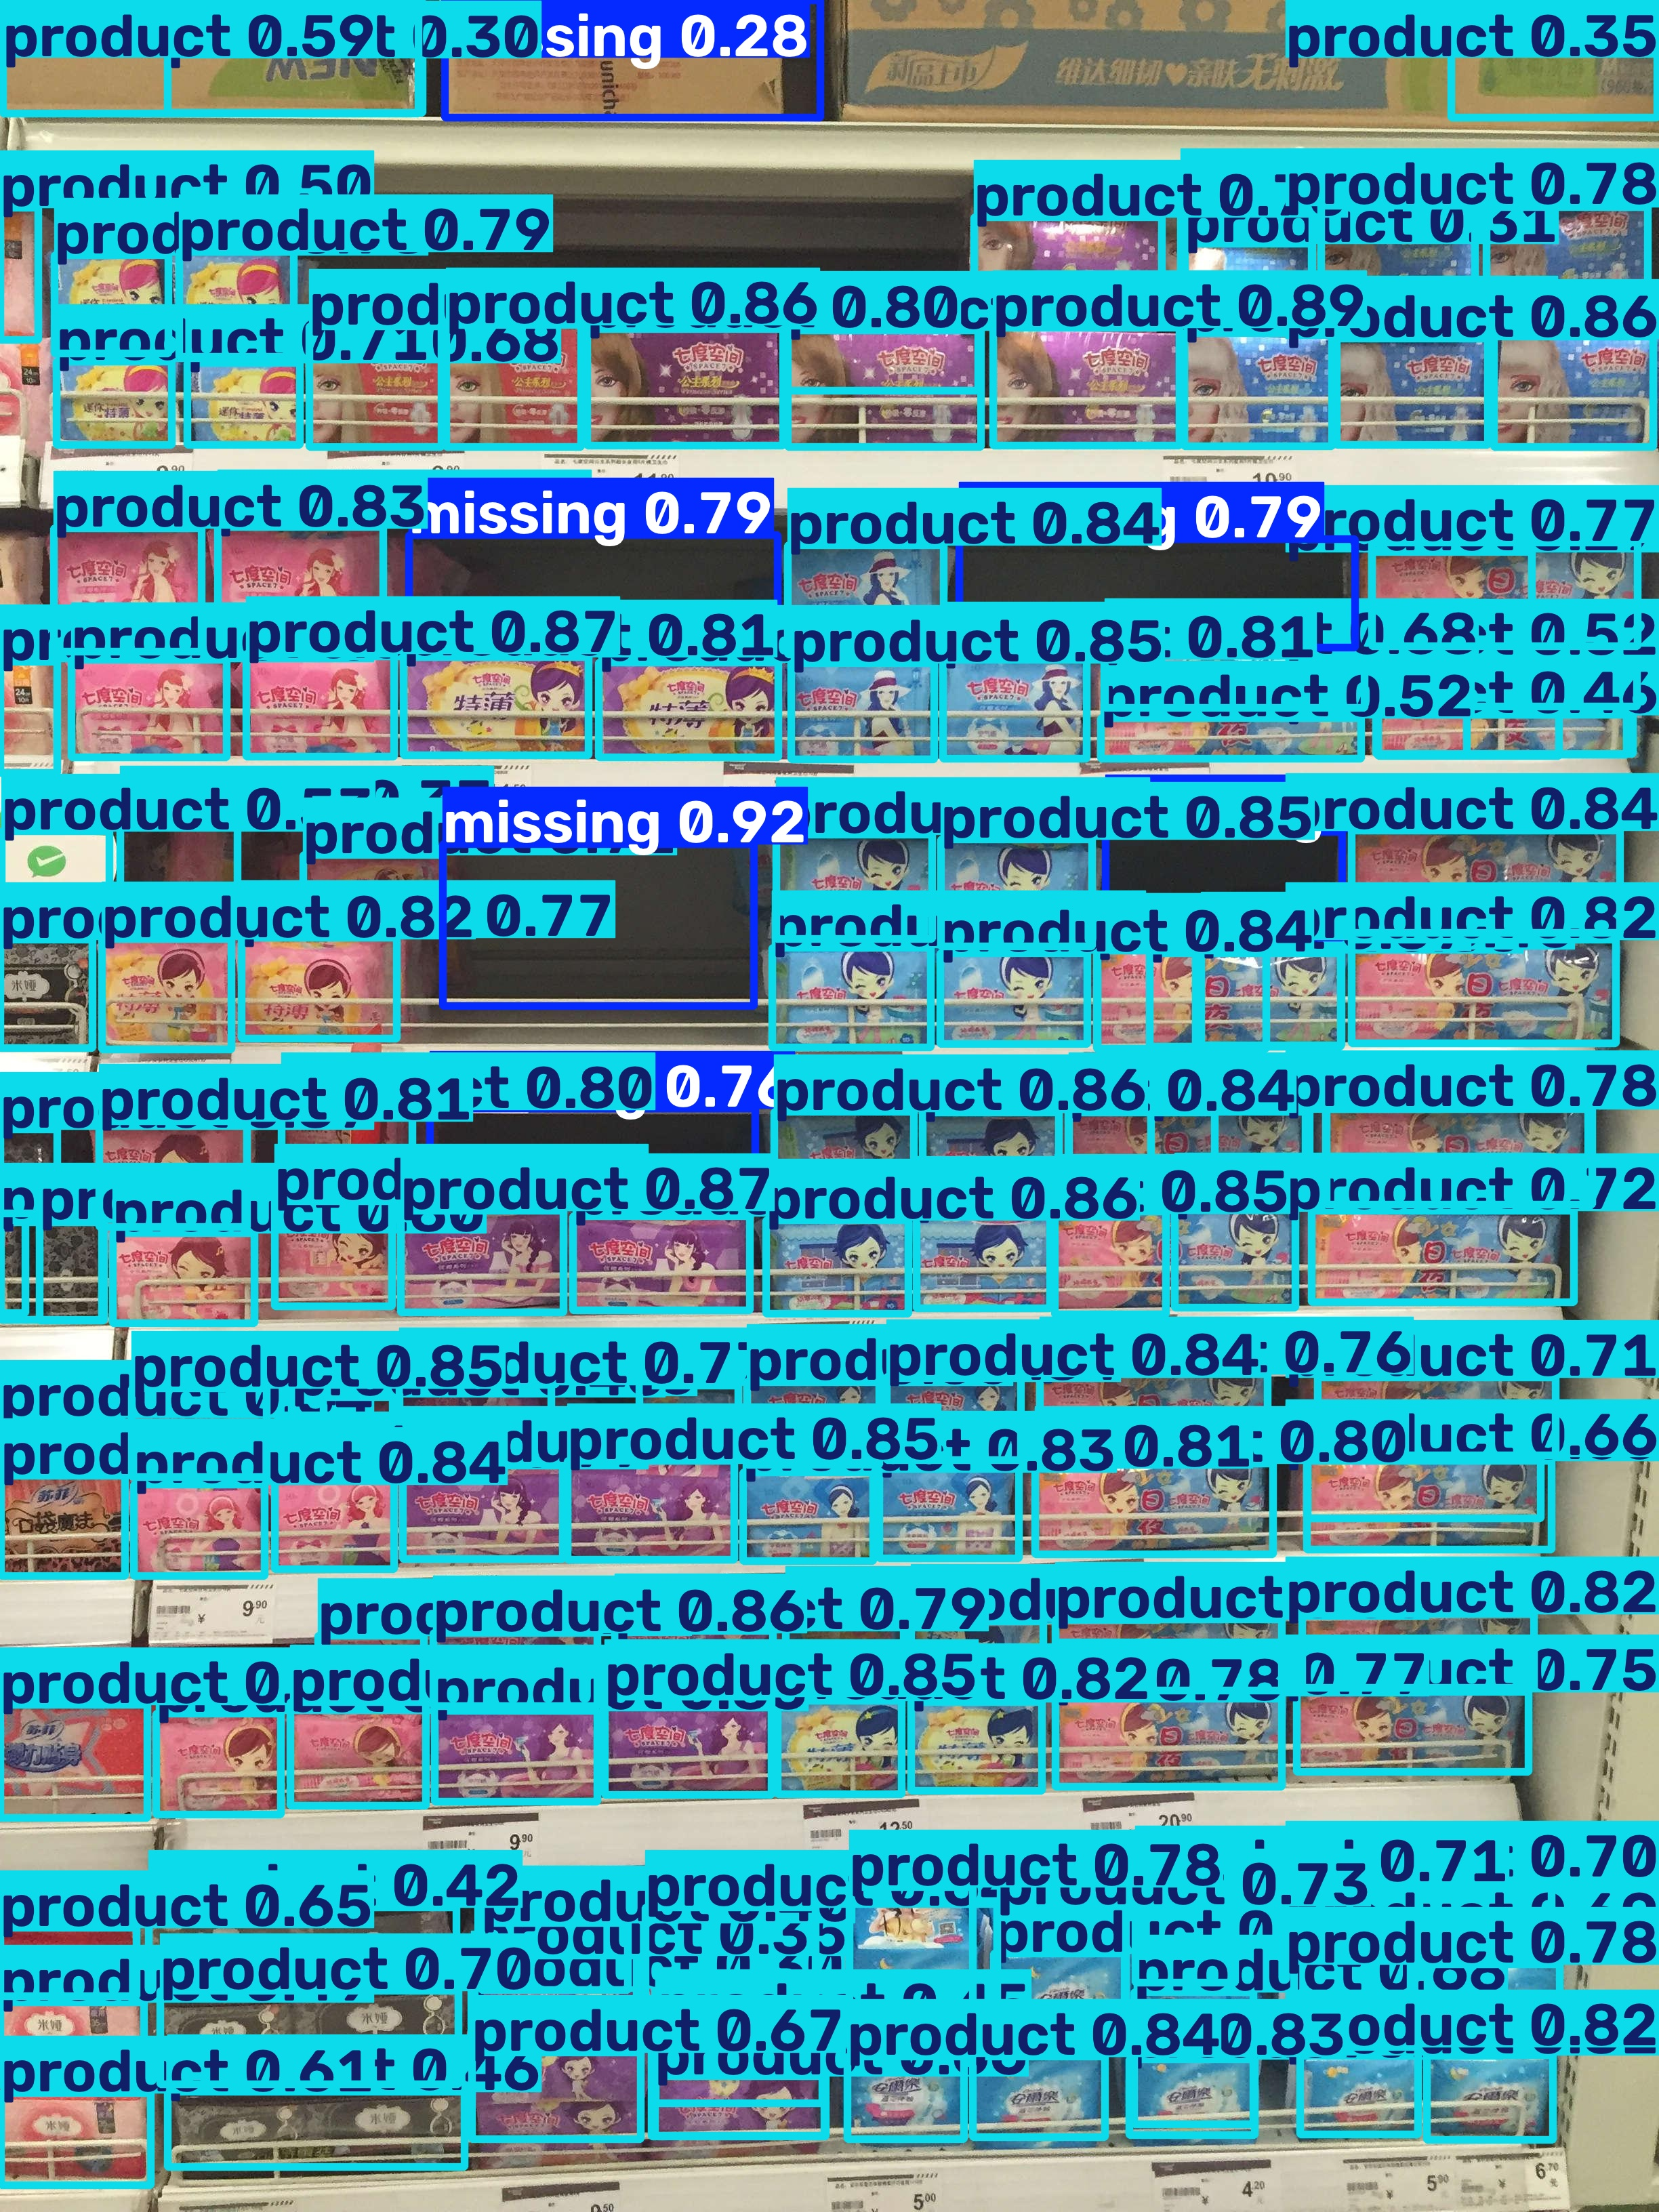

In [ ]:
from IPython.display import Image, display
import os

# Get the path to the saved prediction image
# The save path is obtained from the previous output: '/content/runs/detect/predict'
# The output image name is the same as the input.
predicted_image_path = os.path.join("/content/runs/detect/predict", example_image_name)

if os.path.exists(predicted_image_path):
    print(f"Mostrando predicciones para: {example_image_name}")
    display(Image(filename=predicted_image_path))
else:
    print("No se encontró la imagen predicha. Asegúrate de que el modelo haya guardado los resultados correctamente.")

# You can modify 'example_image_name' in the previous cell and run it again
# to test with another image. For example:
# example_image_name = "train_47_jpg.rf.fdb7496c6d46ebb2c8188898f2196b89.jpg"
# image_to_test = os.path.join(AUG_DATASET_DIR, "valid", "images", example_image_name) # Ensure this points to AUG_DATASET_DIR
# quick_check("/content/runs/detect/train/weights/best.pt", image_to_test)


In [ ]:
import os
for d in ["/content/raw_dataset", "/content/seg_dataset", "/content/final_dataset"]:
    print(d, "->", "existe" if os.path.exists(d) else "NO existe")

In [ ]:
import shutil
from pathlib import Path

# Cleanly recreate AUG_DATASET_DIR to ensure fresh augmentation
if Path(AUG_DATASET_DIR).exists():
    shutil.rmtree(AUG_DATASET_DIR)
Path(AUG_DATASET_DIR).mkdir(parents=True, exist_ok=True)

# Run bounding box augmentation for the training split
augment_train_split_bboxes(RAW_DATASET_DIR, AUG_DATASET_DIR, n_per_image=N_AUGMENTATIONS_PER_IMAGE)

# Copy the 'valid' split from the raw dataset to the augmented dataset (no augmentation for validation)
copy_clean_split("valid", RAW_DATASET_DIR, AUG_DATASET_DIR)

# Get class names from the original dataset's data.yaml
class_names = get_class_names_from_raw_yaml(RAW_DATASET_DIR)

# Write the data.yaml for the augmented dataset
write_data_yaml(AUG_DATASET_DIR, class_names)


In [ ]:
import os
print(os.path.exists("/content/final_dataset/data.yaml"))
print(os.listdir("/content/final_dataset"))

In [ ]:
import os
for base in ["/content/raw_dataset", "/content/seg_dataset"]:
    print(base, "->", os.listdir(base) if os.path.exists(base) else "no existe")

In [ ]:
from google.colab import files
from pathlib import Path
import os

# Dynamically find the latest training run directory (e.g., train-6)
runs_dir = Path('/content/runs/detect')
latest_run_dir = None
if runs_dir.exists():
    run_dirs = sorted([d for d in runs_dir.iterdir() if d.is_dir() and d.name.startswith('train')])
    if run_dirs:
        latest_run_dir = run_dirs[-1] # Get the latest one

if latest_run_dir:
    model_to_download = latest_run_dir / "weights" / "best.pt"
    if model_to_download.exists():
        print(f"Descargando el modelo desde: {model_to_download}")
        files.download(str(model_to_download))
    else:
        print(f"Error: No se encontró 'best.pt' en {model_to_download}. Asegúrate de que el entrenamiento se haya completado exitosamente.")
else:
    print("No se encontraron directorios de entrenamiento. Asegúrate de haber ejecutado el entrenamiento del modelo.")


Descargando el modelo desde: /content/runs/detect/train-6/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>